In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
import sys
print(sys.executable)

/Users/dide/real-time-fraud-detection-ai/venv311/bin/python


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

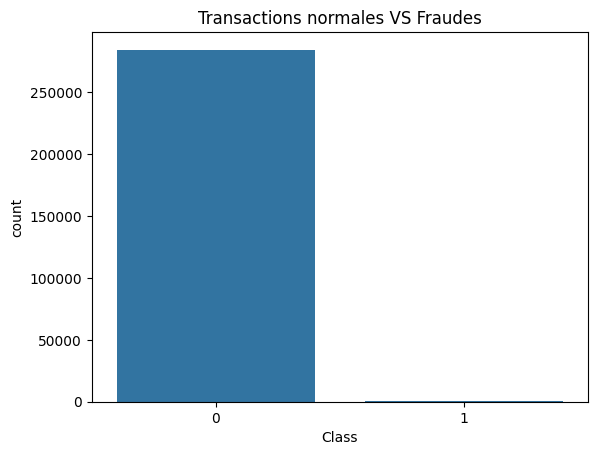

In [6]:
#Visualisation du déséquilibre entre le nombre de fraudes et le nombre de transactions non suspectes
sns.countplot(x="Class", data=df)
plt.title("Transactions normales VS Fraudes")
plt.show()

In [7]:
# Séparation des variables caractéristiques (V1, V2, ...) et de la cible a prédire (Class)
X=df.drop("Class", axis=1)
y=df["Class"]

In [8]:
# Répartition des données d'entrainements et des données tests
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   #Nous prenons 70% du dataset pour les données d'entrainement et 30% pour tests
    random_state=8,  #Pour maintenir la selection des lignes
    stratify=y      #Conserve le ratio de fraude
)

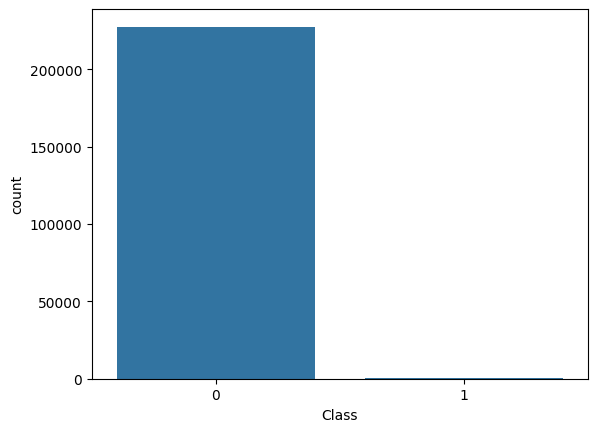

In [9]:
# Visualisation des données d'entrainement
sns.countplot(x=y_train)
plt.title("")
plt.show()

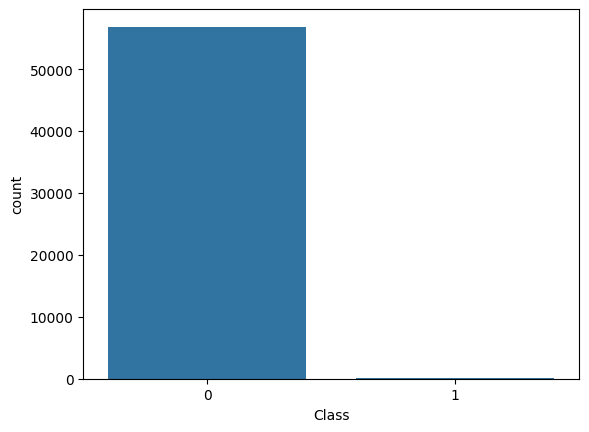

In [10]:
# Visualisation des données tests
sns.countplot(x=y_test)
plt.title("")
plt.show()

In [11]:
# Création et configuration du model
model= XGBClassifier(eval_metric='logloss')   #on pénalise les fausses prédictions (ex: prédire 0.99 alors que c'est faux


In [12]:
# Entrainement du model
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
# Prédictions
y_pred = model.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Constat du report de cette classification
Class 0(transactions normales): on constate que notre modele a une précision 100%, toutes les transactions prédites comme normales étant vraiment normales. Un recall égal à 100% le modele ayant prédites toutes les transactions normales. Ce qui est magnifique.

Class 1(transactions frauduleuses): on constate que notre notre modele a une précision égale à 90% sur cette classe, on a donc une erreur de 10% sur les prédictions de transactions frauduleuses du modèle. Un recall égal à 91%, notre modèle ayant prédit 91% de toutes les vraies transactions suspectes. Ce qui n'est pas mal.

La prochaine étape ici sera d'améliorer notre modèle en améliorant le recall. On a une précision assez élevée. L'amélioration du recall étant plus important que la précision car il faut détecter le plus de fraudes possibles.(manquer une fraude est pire que bloquer une transaction).

In [25]:
# Tester un seuil plus bas pour détecter un maximum de fraudes
y_prob=model.predict_proba(X_test)[:,1]

#on a un seuil standard à 0.5 donc on descend un peu plus bas à 0.3 et on va tester le résultat
seuil=0.3
y_pred_custom=(y_prob>seuil).astype(int)  # si la probabilité est supérieur a 0.3 alors "True" cest une fraude et on covertit en 1

#on evalue maintenant le résultat
print("Avec un seuil à 0.5")
print(classification_report(y_test, y_pred))
      
print("Avec un seuil à 0.3")
print(classification_report(y_test, y_pred_custom))

Avec un seuil à 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Avec un seuil à 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



On constate qu avec un seuil de 0.3 le recall n'augmente pas vraiment

In [26]:
#on test avec un seuil à 0.1
seuil=0.1
y_pred_custom=(y_prob>seuil).astype(int)  # si la probabilité est supérieur a 0.3 alors "True" cest une fraude et on covertit en 1

#on evalue maintenant le résultat
print("Avec un seuil à 0.5")
print(classification_report(y_test, y_pred))
      
print("Avec un seuil à 0.1")
print(classification_report(y_test, y_pred_custom))

Avec un seuil à 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Avec un seuil à 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



On constate que le recall des fraudes augmente très peu et que la précision diminue. Ce nest pas très optimal. Il faut donc trouver un autre moyen d'améliorer notre modele.

Notre dataset étant vraiment déséquilibré nous allons donné plus d'importance aux fraudes. Si notre model fait une erreur sur:
une transaction normale: petite pénalité
une transaction frauduleuse: grosse pénalité

In [ ]:
Pour notre exempleon calcul le poids des fraudes sur les transactions normales
284515/492=598...
Donc on pénalise 500 fois plus notre modele si il trouve qune fraude est une transaction normale

In [29]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(scale_pos_weight)

577.2868020304569


In [31]:
model= XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

In [32]:
# On entraine maintenant le model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#On visualise le résultat
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.88      0.90        98

    accuracy                           1.00     56962
   macro avg       0.96      0.94      0.95     56962
weighted avg       1.00      1.00      1.00     56962

